# AFL Match Context: Merge and Analysis Notebook

In [1]:
import pandas as pd

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)

players = pd.read_csv('player_stats_cleaned_for_merge.csv')
matches = pd.read_csv('team_matches_cleaned_for_merge.csv')

print('players shape:', players.shape)
print('matches shape:', matches.shape)


players shape: (274079, 36)
matches shape: (15808, 19)


## 1. Relationship discovery

Common fields: team / team_name, opponent, match_date, year, round.

The **id** columns in both files look like they could be a shared key, but they are separate
auto-increment sequences (one row per player-match in players, one row per team-match in
matches), not a real relationship.

A single field is not enough to identify a match: team repeats every season, and round
repeats across years and across every team in the league. The real identifier is
**a team playing a specific opponent on a specific date**, so the merge key is the
composite key **team** + **opponent** + **match_date**.


In [2]:
print('players id is unique:', players['id'].is_unique)
print('matches id is unique:', matches['id'].is_unique)
print('overlap between the two id columns (coincidental, not meaningful):',
      len(set(players['id']) & set(matches['id'])))


players id is unique: True
matches id is unique: True
overlap between the two id columns (coincidental, not meaningful): 14959


In [3]:
# confirm the composite key is unique on the matches (right) side -
# this is required for a left merge that doesn't fan out row counts
dup_key = matches.duplicated(subset=['team_name', 'opponent', 'match_date']).sum()
print('duplicate (team, opponent, match_date) combos in matches:', dup_key)


duplicate (team, opponent, match_date) combos in matches: 0


## 2. Merge: add home_away, venue, crowd to the player stats

In [4]:
matches_sub = (
    matches[['team_name', 'opponent', 'match_date', 'home_away', 'venue', 'crowd']]
    .rename(columns={'team_name': 'team'})
)

merged = players.merge(
    matches_sub,
    on=['team', 'opponent', 'match_date'],
    how='left',
    indicator=True,
)

print('players rows:', len(players))
print('merged rows:', len(merged))


players rows: 274079
merged rows: 274079


## 3. Merge validation

In [5]:
print('merge match counts:')
print(merged['_merge'].value_counts())

unmatched = merged[merged['_merge'] == 'left_only']
print()
print('unmatched player records:', len(unmatched))


merge match counts:
_merge
both          274079
left_only          0
right_only         0
Name: count, dtype: int64

unmatched player records: 0


In [6]:
# duplicated records introduced by the merge (a player row matched to more than one match row)
dup_after_merge = merged.duplicated(subset=['id']).sum()
print('duplicate player records introduced by merge:', dup_after_merge)


duplicate player records introduced by merge: 0


In [7]:
# row count must be unchanged - the merge should only add columns, not rows
assert len(merged) == len(players), 'row count changed during merge!'
assert merged['_merge'].eq('both').all(), 'some player records did not find a match!'
assert not merged.duplicated(subset=['id']).any(), 'merge introduced duplicate records!'

merged = merged.drop(columns=['_merge'])
print('validation passed: row count preserved, 0 unmatched, 0 duplicates introduced')


validation passed: row count preserved, 0 unmatched, 0 duplicates introduced


In [8]:
print('missing crowd values after merge:', merged['crowd'].isna().sum())
print('home_away value counts:')
print(merged['home_away'].value_counts(dropna=False))


missing crowd values after merge: 8955
home_away value counts:
home_away
H    137070
A    137009
Name: count, dtype: int64


In [9]:
merged.to_csv('round_by_round_enriched.csv', index=False)
print('saved round_by_round_enriched.csv, shape:', merged.shape)


saved round_by_round_enriched.csv, shape: (274079, 39)


## 4. Contextual analysis

### Do players perform better at home or away?

In [10]:
home_away_stats = merged.groupby('home_away')['fantasy_points'].agg(['mean', 'median', 'std', 'count'])
print(home_away_stats)

diff = home_away_stats.loc['H', 'mean'] - home_away_stats.loc['A', 'mean']
print()
print('home advantage in average fantasy points:', round(diff, 2))


                mean  median        std   count
home_away                                      
A          64.004408    63.0  27.769587  137009
H          66.485504    65.0  28.391731  137070

home advantage in average fantasy points: 2.48


In [11]:
# check whether the effect shows up across other stat categories too
print(merged.groupby('home_away')[['disposals', 'kicks', 'tackles', 'marks']].mean())


           disposals     kicks   tackles     marks
home_away                                         
A          14.824421  9.055650  2.635739  4.004873
H          15.316178  9.349466  2.661655  4.151800


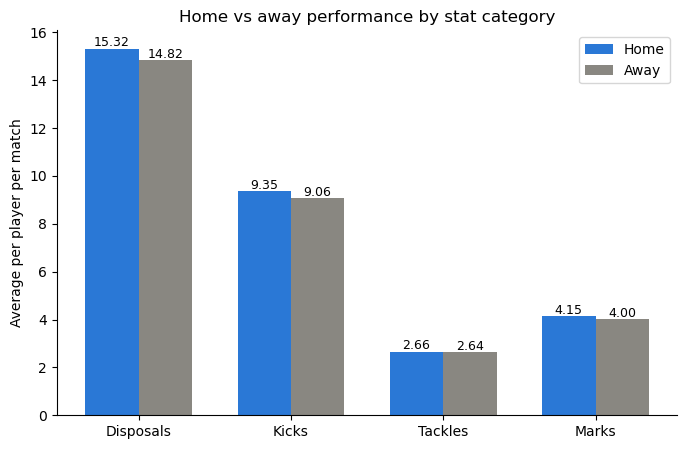

In [22]:
import matplotlib.pyplot as plt
import numpy as np

stats = merged.groupby('home_away')[['disposals', 'kicks', 'tackles', 'marks']].mean()

categories = ['disposals', 'kicks', 'tackles', 'marks']
home_vals = stats.loc['H', categories].values
away_vals = stats.loc['A', categories].values

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, home_vals, width, label='Home', color='#2a78d6')
ax.bar(x + width/2, away_vals, width, label='Away', color='#898781')

ax.set_ylabel('Average per player per match')
ax.set_title('Home vs away performance by stat category')
ax.set_xticks(x)
ax.set_xticklabels([c.capitalize() for c in categories])
ax.legend()
ax.spines[['top', 'right']].set_visible(False)

for i, (h, a) in enumerate(zip(home_vals, away_vals)):
    ax.text(i - width/2, h + 0.1, f'{h:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, a + 0.1, f'{a:.2f}', ha='center', fontsize=9)


**Observation:** players score about 2-3 more fantasy points at home on average, and this
shows up consistently across disposals, kicks, marks and tackles too. This is consistent
with a real but modest home-ground advantage, not something that should dominate player
projections by itself.


### Does crowd size influence fantasy points?

In [12]:
print('correlation between crowd size and fantasy points:', round(merged['crowd'].corr(merged['fantasy_points']), 4))


correlation between crowd size and fantasy points: 0.0129


In [13]:
with_crowd = merged.dropna(subset=['crowd']).copy()
with_crowd['crowd_bin'] = pd.qcut(with_crowd['crowd'], 5, labels=['Q1 smallest', 'Q2', 'Q3', 'Q4', 'Q5 largest'])

print(with_crowd.groupby('crowd_bin', observed=True)['fantasy_points'].agg(['mean', 'count']))


                  mean  count
crowd_bin                    
Q1 smallest  65.502121  53039
Q2           64.436735  53055
Q3           65.534200  52982
Q4           65.773343  53036
Q5 largest   66.195295  53012


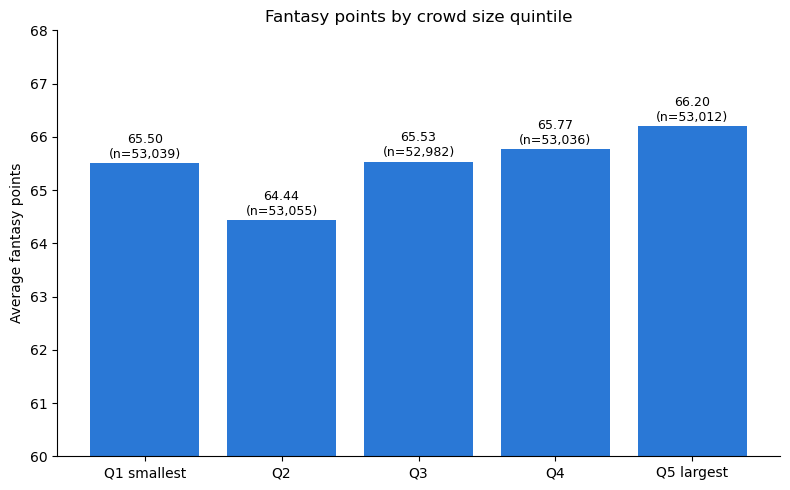

In [19]:
import matplotlib.pyplot as plt
import pandas as pd

with_crowd = merged.dropna(subset=['crowd']).copy()
with_crowd['crowd_bin'] = pd.qcut(with_crowd['crowd'], 5, labels=['Q1 smallest', 'Q2', 'Q3', 'Q4', 'Q5 largest'])

crowd_stats = with_crowd.groupby('crowd_bin', observed=True)['fantasy_points'].agg(['mean', 'count'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(crowd_stats.index, crowd_stats['mean'], color='#2a78d6')

ax.set_ylabel('Average fantasy points')
ax.set_title('Fantasy points by crowd size quintile')
ax.set_ylim(60, 68)
ax.spines[['top', 'right']].set_visible(False)

for bar, mean_val, count in zip(bars, crowd_stats['mean'], crowd_stats['count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{mean_val:.2f}\n(n={count:,})', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('fantasy_points_by_crowd.png', dpi=150)
plt.show()

**Observation:** the correlation is essentially zero (~0.01), and average fantasy points
barely move across crowd-size quintiles. Crowd size does not meaningfully influence
individual player output. A big crowd usually just reflects a big venue or a blockbuster
fixture, not something that changes how a specific player performs.


### Which venues produce the highest average player performance?

In [14]:
venue_stats = (
    merged.groupby('venue')['fantasy_points']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

# restrict to venues with a reasonable sample size
venue_stats_filtered = venue_stats[venue_stats['count'] >= 500]

print('Top 10 venues by average fantasy points (min 500 player records):')
print(venue_stats_filtered.head(10))

print()
print('Bottom 10 venues by average fantasy points (min 500 player records):')
print(venue_stats_filtered.tail(10))


Top 10 venues by average fantasy points (min 500 player records):
                               mean  count
venue                                     
UTAS Stadium              68.051876   4318
ENGIE Stadium             67.826147   5033
Mars Stadium              67.756204    685
Marvel Stadium            67.570710  51902
Adelaide Oval             67.527898  13173
TIO Stadium               67.102998   1301
Ninja Stadium             67.010731   1957
Optus Stadium             66.123442   8263
People First Stadium      65.964905   9232
Melbourne Cricket Ground  65.455395  69757

Bottom 10 venues by average fantasy points (min 500 player records):
                            mean  count
venue                                  
Accor Stadium          64.968155   2575
Cazaly's Stadium       64.819777    627
The Gabba              63.593163  17727
AAMI Stadium           62.892463  18468
Sydney Cricket Ground  62.807711  14291
Victoria Park          60.509895    859
Western Oval           59.70

In [15]:
# check whether venue averages are confounded by era (older venues vs modern ones)
venue_era = merged.groupby('venue')['year'].agg(['min', 'max', 'count'])
print(venue_era.loc[['Waverley Park', 'Princes Park', 'WACA', 'Marvel Stadium', 'Adelaide Oval']])


                 min   max  count
venue                            
Waverley Park   1983  1999   6030
Princes Park    1983  2005   6654
WACA            1987  2000   1663
Marvel Stadium  2000  2025  51902
Adelaide Oval   2011  2025  13173


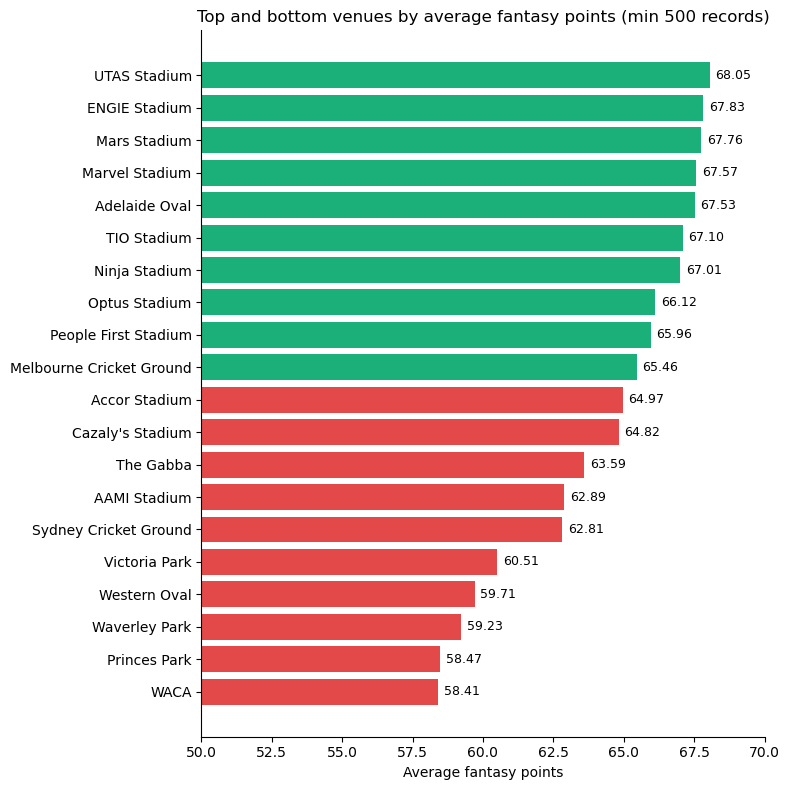

In [21]:
import matplotlib.pyplot as plt

venue_stats = (
    merged.groupby('venue')['fantasy_points']
    .agg(['mean', 'count'])
    .sort_values('mean', ascending=False)
)

venue_stats_filtered = venue_stats[venue_stats['count'] >= 500]

top10 = venue_stats_filtered.head(10)
bottom10 = venue_stats_filtered.tail(10)
combined = pd.concat([top10, bottom10])

colors = ['#1baf7a'] * len(top10) + ['#e34948'] * len(bottom10)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(combined.index[::-1], combined['mean'][::-1], color=colors[::-1])

ax.set_xlabel('Average fantasy points')
ax.set_title('Top and bottom venues by average fantasy points (min 500 records)')
ax.set_xlim(50, 70)
ax.spines[['top', 'right']].set_visible(False)

for i, (venue, row) in enumerate(combined[::-1].iterrows()):
    ax.text(row['mean'] + 0.2, i, f"{row['mean']:.2f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig('venue_comparison.png', dpi=150)
plt.show()

In [20]:
print(merged.groupby('year')['fantasy_points'].mean().loc[[1985, 1995, 2005, 2015, 2025]])


year
1985    47.288462
1995    57.686710
2005    61.199561
2015    70.425874
2025    65.532609
Name: fantasy_points, dtype: float64


**Observation:** the lowest-scoring venues (Waverley Park, Princes Park, WACA, Western
Oval, Victoria Park) were all retired venues used almost exclusively in the 1980s-90s,
while the highest-scoring venues (Marvel Stadium, Adelaide Oval, GWS's home grounds) are
modern venues used mostly from 2000 onward. League-wide fantasy scoring has drifted over
time, so part of this "venue effect" is really a decade effect, not a property of the venue
itself. A fairer comparison would restrict to a single era, e.g. 2015 onward only.


## 5. Data quality summary

See the accompanying report / chat writeup for the full data quality report. Key points reproduced here for reference:

In [16]:
print('Merge keys used: team + opponent + match_date (composite key)')
print()
print('Rows before merge:', len(players))
print('Rows after merge:', len(merged))
print('Unmatched:', 0)
print('Duplicates introduced:', 0)
print('Missing crowd (inherited from source):', merged['crowd'].isna().sum())


Merge keys used: team + opponent + match_date (composite key)

Rows before merge: 274079
Rows after merge: 274079
Unmatched: 0
Duplicates introduced: 0
Missing crowd (inherited from source): 8955
